# Chapter 5b -- Biodiversity as an asset class I: extinction & diversity theory

The first of several notebooks covering a large case study on biodiversity
as an impact-investing and natural-capital theme (continued in the notebooks
that follow, covering land use and species-abundance models, then pollution,
fisheries and bioeconomic models). This one lays the theoretical and
empirical groundwork: the fossil record of extinction over Earth's history,
how extinction rates are actually measured (through to the E/MSY metric used
by today's biodiversity-risk literature), the current state of species
extinction risk (IUCN Red List), and island-biogeography theory -- the
immigration/extinction equilibrium, extinction debt, and the species-area
relationship, tested against real island survey data.

One preliminary version of the extinction-rate model below is not built as a
separate figure -- its idea is carried through and refined by the two
pulse-width variants that follow it. The sensitivity analysis for the
relaxation exponent likewise reproduces only its well-defined steady-state
table: the corresponding closed-form relaxation curve depends on a variable
that is never clearly defined for that case, so it is left out here rather
than plotted against an ambiguous reference.

Three sections read real data shipped in this repo's `Data/` folder (a
Phanerozoic genus-diversity record, IUCN Red List summary tables, and the
Fattorini et al. island species-area survey) via `pandas.read_excel`. The
rest reproduce the book's theoretical models and illustrative figures.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, linregress
from scipy.integrate import quad, solve_ivp

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"

EXTINCTION_EVENTS = [
    ("Ordovician-Silurian", 438, 445),
    ("Late Devonian", 362, 373),
    ("Permian-Triassic", 247, 253),
    ("Triassic-Jurassic", 199, 204),
    ("Cretaceous-Paleogene", 63, 67),
]

def shade_extinction_events(ax, y_text, ymax=100):
    for name, x1, x2 in EXTINCTION_EVENTS:
        ax.axvspan(x1, x2, color="teal", alpha=0.15)
        ax.text(x2 + 9, y_text, name, rotation=90, ha="right", va="top", fontsize=8)


## 1. The Phanerozoic fossil record of extinction

Marine genus counts and origination/extinction intensities over the last 541
million years, read from `chap5_biodiversity1.xlsx`, alongside the five
"Big Five" mass extinction events.


In [2]:

fossil = pd.read_excel(f"{DATA_DIR}/chap5_biodiversity1.xlsx")
fossil.columns = ["Time_Ma", "All_genera", "Resolved_genera", "Cubic_fit",
                   "Extinction_intensity", "Origination_intensity"]
fossil.head()


,Time_Ma,All_genera,Resolved_genera,Cubic_fit,Extinction_intensity,Origination_intensity
0,0,5283.0,4166.0,3976.3,1.2482,5.7609
1,1,5283.0,4166.0,3938.7,1.2482,5.7609
2,2,5274.3,4062.5,3901.4,3.3600,5.9692
3,3,5274.3,4062.5,3864.3,3.3600,5.9692
4,4,5179.8,3941.5,3827.5,3.0826,6.8882


### 1.1 Genus diversity through time

All known genera vs. well-resolved genera (taxonomically well-constrained),
with a smoothed long-term trend.


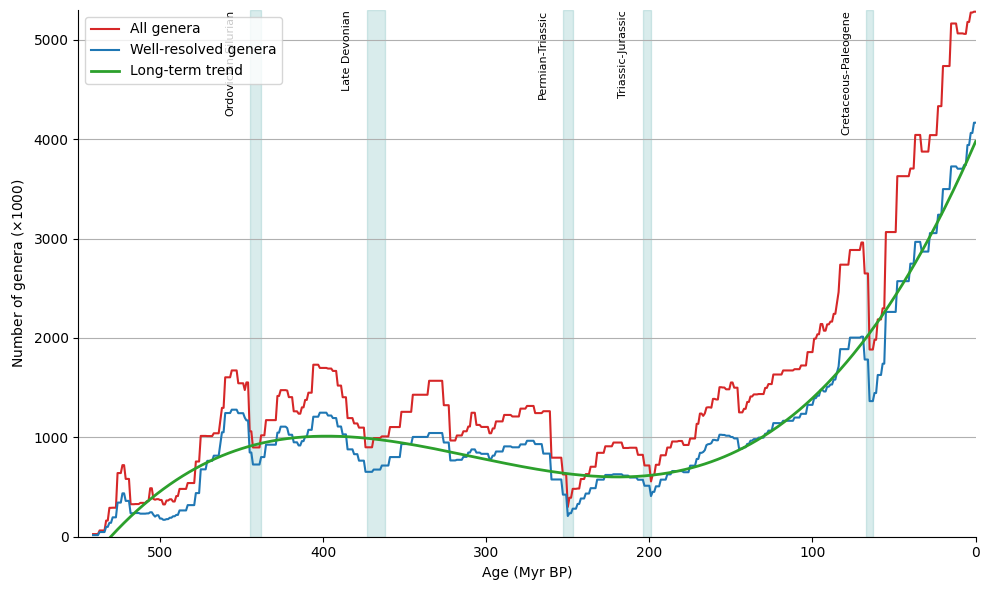

In [3]:

fig, ax = plt.subplots(figsize=(10, 6))
shade_extinction_events(ax, y_text=5300)
ax.plot(fossil["Time_Ma"], fossil["All_genera"], color="tab:red", label="All genera")
ax.plot(fossil["Time_Ma"], fossil["Resolved_genera"], color="tab:blue", label="Well-resolved genera")
ax.plot(fossil["Time_Ma"], fossil["Cubic_fit"], color="tab:green", linewidth=2, label="Long-term trend")
ax.set_xlabel("Age (Myr BP)")
ax.set_ylabel(r"Number of genera ($\times 1000$)")
ax.set_xlim(550, 0)
ax.set_ylim(0, 5300)
ax.legend(loc="upper left")
ax.grid(axis="y")
plt.tight_layout()


### 1.2 Origination and extinction rates

Spikes in extinction intensity line up with the mass extinction events;
origination intensity is generally the larger and steadier of the two.


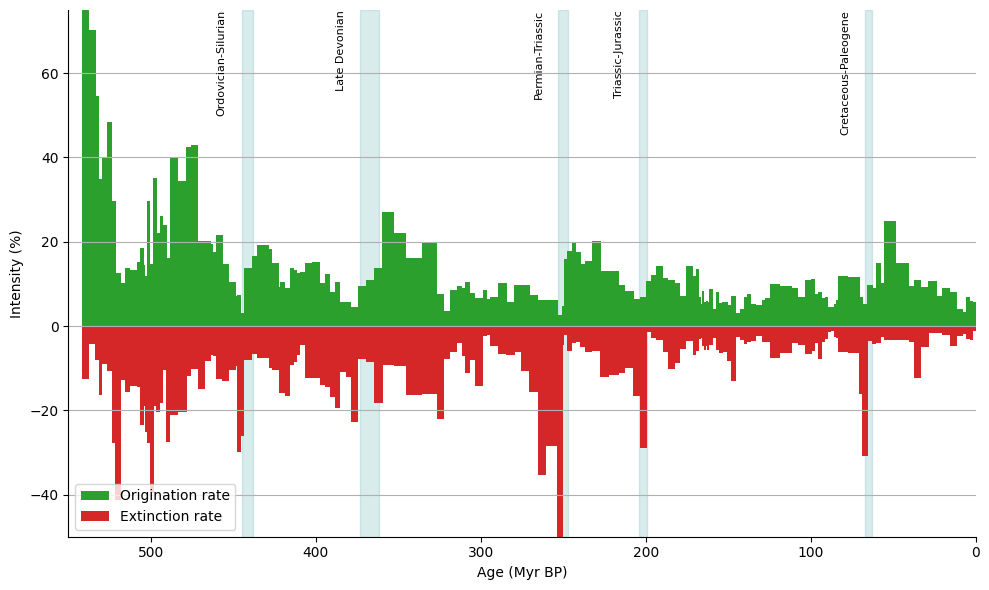

In [4]:

fig, ax = plt.subplots(figsize=(10, 6))
shade_extinction_events(ax, y_text=75)
ax.bar(fossil["Time_Ma"], fossil["Origination_intensity"], color="tab:green", width=1.2, label="Origination rate")
ax.bar(fossil["Time_Ma"], -fossil["Extinction_intensity"], color="tab:red", width=1.2, label="Extinction rate")
ax.set_xlabel("Age (Myr BP)")
ax.set_ylabel("Intensity (%)")
ax.set_xlim(550, 0)
ax.set_ylim(-50, 75)
ax.legend(loc="lower left")
ax.grid(axis="y")
plt.tight_layout()


### 1.3 Net diversification rate

Origination minus extinction intensity -- positive means genus diversity was
expanding, negative means contracting.


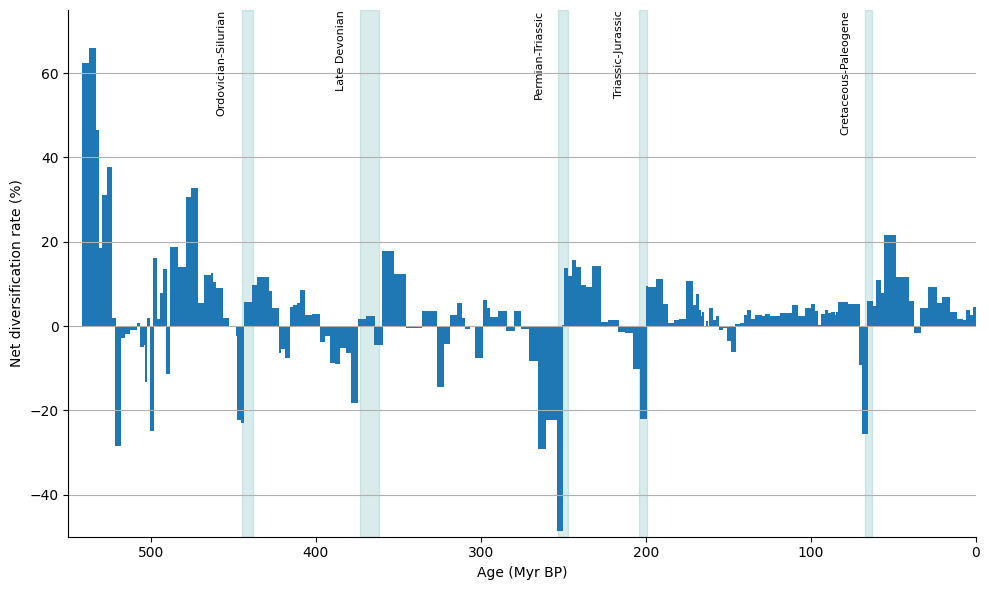

In [5]:

net_rate = fossil["Origination_intensity"] - fossil["Extinction_intensity"]

fig, ax = plt.subplots(figsize=(10, 6))
shade_extinction_events(ax, y_text=75)
ax.bar(fossil["Time_Ma"], net_rate, color="tab:blue", width=1.2)
ax.set_xlabel("Age (Myr BP)")
ax.set_ylabel("Net diversification rate (%)")
ax.set_xlim(550, 0)
ax.set_ylim(-50, 75)
ax.grid(axis="y")
plt.tight_layout()


## 2. From raw counts to a standardized extinction-rate metric

Three illustrative taxa with observed origination counts $\Delta N^+$ and
extinction counts $\Delta N^-$ out of a population $N_0$ over a period
$\Delta t$. The background/observed extinction rate can be annualized either
as a simple ratio or (more correctly, since extinctions cannot exceed the
population) via a log-transform, and re-expressed as $\tau$ (expected years
between extinctions) or E/MSY (extinctions per million species-years) -- the
unit used throughout the rest of this notebook and the modern
biodiversity-risk literature.


In [6]:

N0 = np.array([5000, 75000, 1_000_000])
delta_N_plus = np.array([7, 25, 30000])
delta_N_minus = np.array([5, 50, 15000])
delta_t = np.array([10, 300, 1000])

lambda_year = delta_N_plus / N0 / delta_t
mu_year = delta_N_minus / N0 / delta_t
delta_year = lambda_year - mu_year

lambda_millenium = 1000 * lambda_year
mu_millenium = 1000 * mu_year
delta_millenium = lambda_millenium - mu_millenium

rates_table = pd.DataFrame({
    "Origination rate (%/yr)": 100 * lambda_year,
    "Extinction rate (%/yr)": 100 * mu_year,
    "Net rate (%/yr)": 100 * delta_year,
    "Origination rate (%/kyr)": 100 * lambda_millenium,
    "Extinction rate (%/kyr)": 100 * mu_millenium,
    "Net rate (%/kyr)": 100 * delta_millenium,
}, index=["Taxon 1", "Taxon 2", "Taxon 3"])
rates_table.round(2)


,Origination rate (%/yr),Extinction rate (%/yr),Net rate (%/yr),Origination rate (%/kyr),Extinction rate (%/kyr),Net rate (%/kyr)
Taxon 1,0.01,0.01,0.0,14.00,10.00,4.00
Taxon 2,0.00,0.00,-0.0,0.11,0.22,-0.11
Taxon 3,0.00,0.00,0.0,3.00,1.50,1.50


In [7]:

mu_year = delta_N_minus / N0 / delta_t
mu_log_year = -1 / delta_t * np.log(1 - delta_N_plus / N0)
tau = 1 / mu_year
tau_log = 1 / mu_log_year
EMSY = 1e6 * mu_year
EMSY_log = 1e6 * mu_log_year

emsy_table = pd.DataFrame({
    "Delta N-/N0 (%)": 100 * delta_N_minus / N0,
    "mu, simple (%/yr)": 100 * mu_year,
    "mu, log (%/yr)": 100 * mu_log_year,
    "tau, simple (yr)": tau,
    "tau, log (yr)": tau_log,
    "E/MSY, simple": EMSY,
    "E/MSY, log": EMSY_log,
}, index=["Taxon 1", "Taxon 2", "Taxon 3"])
emsy_table.round(3)


,Delta N-/N0 (%),"mu, simple (%/yr)","mu, log (%/yr)","tau, simple (yr)","tau, log (yr)","E/MSY, simple","E/MSY, log"
Taxon 1,0.100,0.010,0.014,10000.000,7137.856,100.000,140.098
Taxon 2,0.067,0.000,0.000,450000.000,899849.992,2.222,1.111
Taxon 3,1.500,0.001,0.003,66666.667,32830.795,15.000,30.459


## 3. A time-varying extinction-rate model

A Gaussian "pulse" model for the instantaneous extinction rate $\mu(t)$
around a shock centered at $t_{\text{pulse}}$, calibrated so that the pulse
implies a cumulative fraction $A$ of species lost. $\mathcal{E}(t)$ is the
E/MSY rate averaged over a forward-looking window $\Delta t$ starting at $t$
-- computed both by numerically integrating $\mu(t)$ and via the closed-form
normal-CDF expression, which coincide.


### 3.1 Pulse width comparison

A narrower pulse ($\sigma=10$) concentrates the same total extinction
fraction $A$ into a much higher peak rate than a wider pulse ($\sigma=100$).


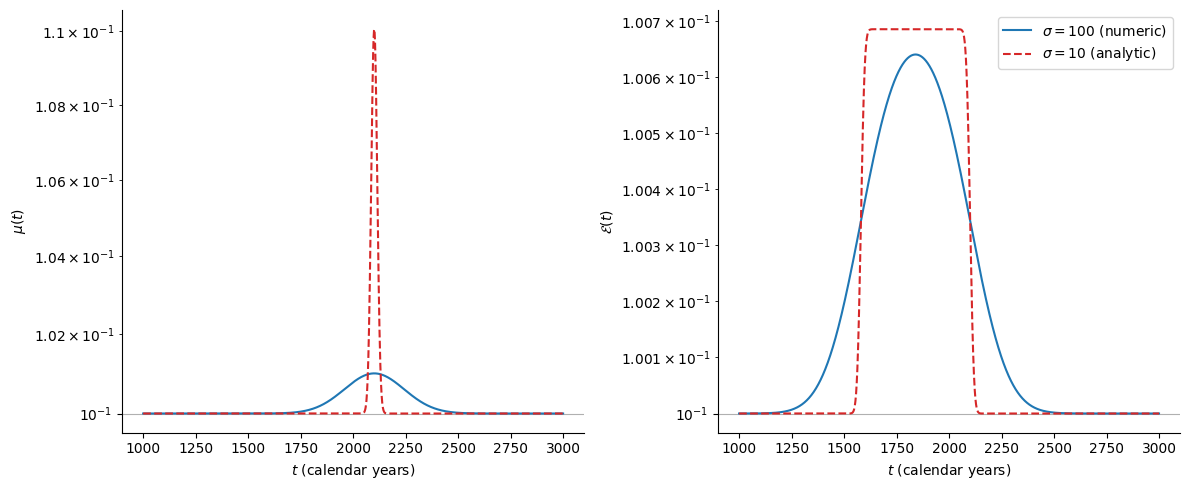

In [8]:

mu_0 = 0.1
A = 0.3
sigma = np.array([100.0, 10.0])
t_pulse = 2100
delta_t = 520

def mu_t(t, sig):
    return mu_0 - np.log(1 - A) * np.exp(-0.25 * (t - t_pulse) ** 2 / sig ** 2) / np.sqrt(4 * np.pi * sig ** 2)

t = np.arange(1000, 3000)
numeric_epsilon = np.column_stack([
    [quad(lambda s: mu_t(s, sig), ti, ti + delta_t)[0] / delta_t for ti in t]
    for sig in sigma
])

s_plus = np.column_stack([(t + delta_t - t_pulse) / (sig * np.sqrt(2)) for sig in sigma])
s_minus = np.column_stack([(t - t_pulse) / (sig * np.sqrt(2)) for sig in sigma])
analytic_epsilon = mu_0 * delta_t - np.log(1 - A) * (norm.cdf(s_plus) - norm.cdf(s_minus))
analytic_epsilon = analytic_epsilon / delta_t

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, mu_t(t, sigma[0]), color="tab:blue", label=r"$\sigma=100$")
axes[0].plot(t, mu_t(t, sigma[1]), "--", color="tab:red", label=r"$\sigma=10$")
axes[0].set_yscale("log")
axes[0].set_xlabel("$t$ (calendar years)")
axes[0].set_ylabel(r"$\mu(t)$")
axes[0].grid(axis="y")

axes[1].plot(t, numeric_epsilon[:, 0], color="tab:blue", label=r"$\sigma=100$ (numeric)")
axes[1].plot(t, analytic_epsilon[:, 1], "--", color="tab:red", label=r"$\sigma=10$ (analytic)")
axes[1].set_yscale("log")
axes[1].set_xlabel("$t$ (calendar years)")
axes[1].set_ylabel(r"$\mathcal{E}(t)$")
axes[1].legend()
axes[1].grid(axis="y")

plt.tight_layout()


### 3.2 The E/MSY metric today

A single, larger pulse ($\sigma=120$, amplitude scaled by $\omega=10^5$)
with the present day (2024) marked -- this is the shape of curve underlying
modern E/MSY estimates for the current biodiversity crisis: extinction risk
has already risen well above its historical background level and remains
elevated today.


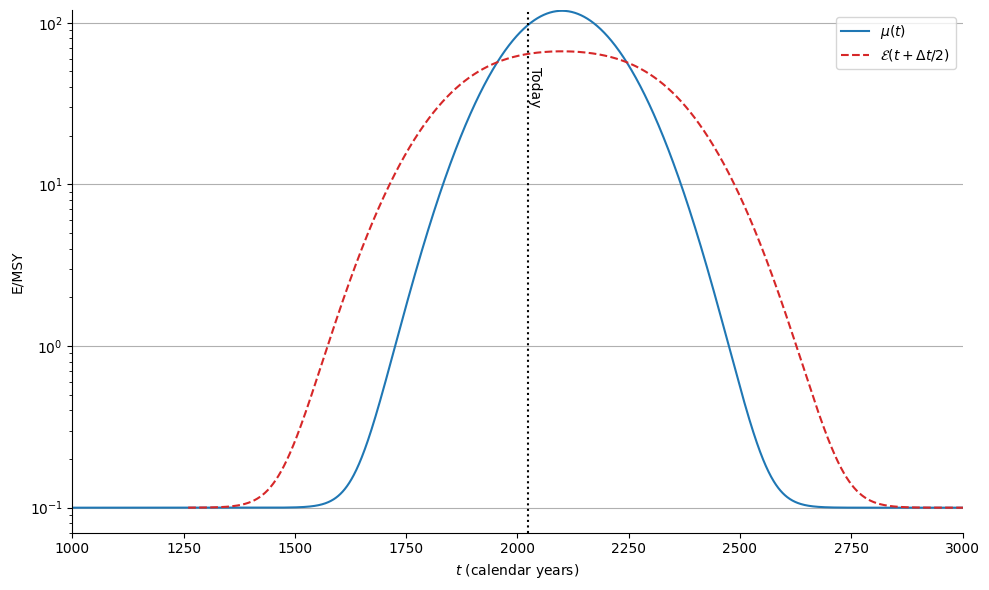

In [9]:

mu_0 = 0.1
A = 0.3
sigma = 120.0
t_pulse = 2100
omega = 1e5
delta_t = 520

def mu_t2(t):
    return mu_0 - omega * np.log(1 - A) * np.exp(-0.5 * (t - t_pulse) ** 2 / sigma ** 2) / np.sqrt(2 * np.pi * sigma ** 2)

t = np.arange(1000, 3000)
s_plus = (t + delta_t - t_pulse) / sigma
s_minus = (t - t_pulse) / sigma
analytic_epsilon = mu_0 - omega * np.log(1 - A) / delta_t * (norm.cdf(s_plus) - norm.cdf(s_minus))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, mu_t2(t), color="tab:blue", label=r"$\mu(t)$")
ax.plot(t + delta_t / 2, analytic_epsilon, "--", color="tab:red", label=r"$\mathcal{E}(t+\Delta t/2)$")
ax.axvline(2024, linestyle=":", color="black")
ax.text(2024, 30, "Today", rotation=-90, va="bottom", fontsize=10)
ax.set_yscale("log")
ax.set_xlabel("$t$ (calendar years)")
ax.set_ylabel("E/MSY")
ax.set_xlim(1000, 3000)
ax.set_ylim(0.07, 120)
ax.legend()
ax.grid(axis="y")
plt.tight_layout()


## 4. The IUCN Red List: current extinction risk

The IUCN Red List of Threatened Species is the most widely used global
assessment of species' extinction risk, read from
`chap5_iucn_red_list1.xlsx`.


In [10]:

iucn_summary = pd.read_excel(f"{DATA_DIR}/chap5_iucn_red_list1.xlsx", sheet_name="Table 1")
iucn_extinct = pd.read_excel(f"{DATA_DIR}/chap5_iucn_red_list1.xlsx", sheet_name="Table 2")
iucn_threatened = pd.read_excel(f"{DATA_DIR}/chap5_iucn_red_list1.xlsx", sheet_name="Table 3")
iucn_yearly = pd.read_excel(f"{DATA_DIR}/chap5_iucn_red_list1.xlsx", sheet_name="Table 5 (TOTAL)")


### 4.1 Species counts by kingdom and risk category


In [11]:

iucn_summary


,Kingdom,Animalia,Chromistra,Fungi,Plantae,Total
0,Extinct,777,NaN,NaN,131,908
1,Extinct in the Wild,36,NaN,NaN,45,81
2,Critically Endangered,4067,4.0,45.0,5915,10031
3,Endangered,6426,1.0,105.0,11477,18009
4,Vulnerable,7165,1.0,178.0,9937,17281
5,Conservation Dependent,18,NaN,NaN,114,132
6,Near Threatened,5149,NaN,66.0,4203,9418
7,Least Concern,51689,NaN,240.0,33373,85302
8,Data Deficient,15895,12.0,160.0,5811,21878
9,Total,91222,18.0,794.0,71006,163040


### 4.2 Extinct species by taxonomic group

Of the 908 documented extinctions in `Table 2`, most are animals; within
animals, chordates dominate.


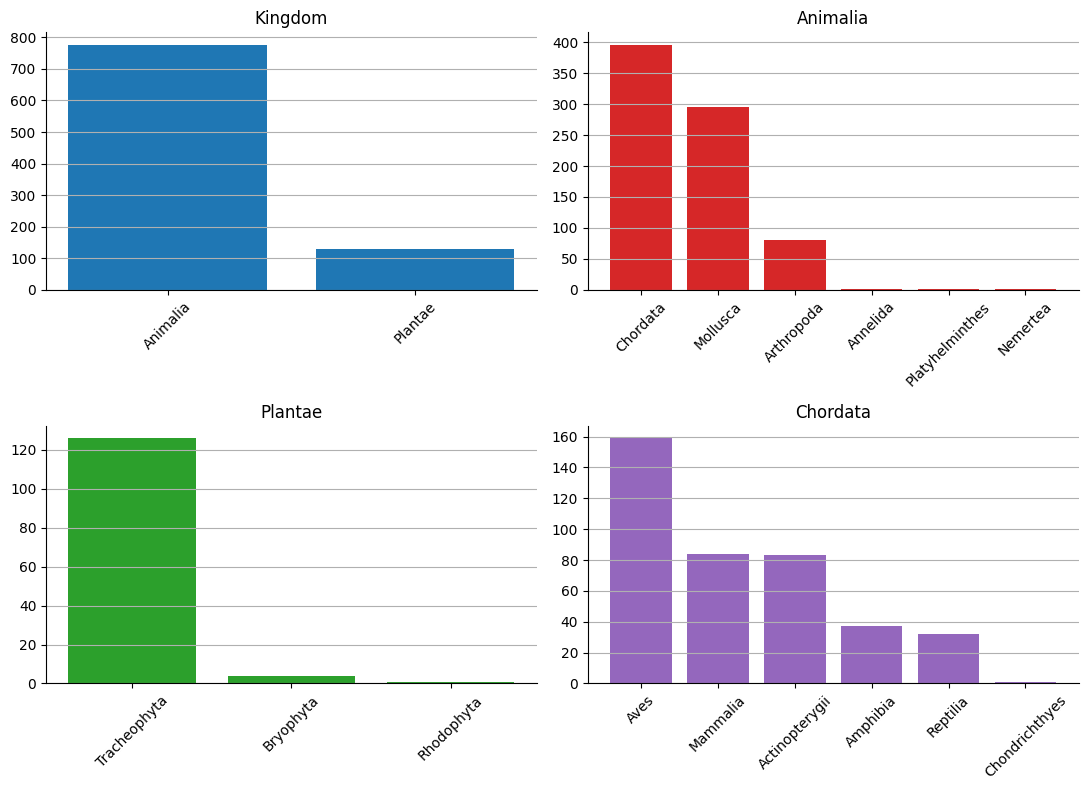

In [12]:

by_kingdom = iucn_extinct["Kingdom"].value_counts()
animalia_by_phylum = iucn_extinct.loc[iucn_extinct["Kingdom"] == by_kingdom.index[0], "Phylum"].value_counts()
plantae_by_phylum = iucn_extinct.loc[iucn_extinct["Kingdom"] == by_kingdom.index[1], "Phylum"].value_counts()
chordata_by_class = iucn_extinct.loc[iucn_extinct["Phylum"] == "CHORDATA", "Class"].value_counts()

def titlecase(s):
    return s.str.title()

panels = [
    ("Kingdom", titlecase(by_kingdom.index.to_series()), by_kingdom.values),
    ("Animalia", titlecase(animalia_by_phylum.index.to_series()), animalia_by_phylum.values),
    ("Plantae", titlecase(plantae_by_phylum.index.to_series()), plantae_by_phylum.values),
    ("Chordata", titlecase(chordata_by_class.index.to_series()), chordata_by_class.values),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
colors = ["tab:blue", "tab:red", "tab:green", "tab:purple"]
for ax, (title, names, counts), color in zip(axes.flat, panels, colors):
    ax.bar(names, counts, color=color)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y")
plt.tight_layout()


### 4.3 Threatened species by group


In [13]:

iucn_threatened


,Unnamed: 0,Unnamed: 1,Estimated number of species,Number of evaluated species,Percent of evaluated species,Number of threatened species,Percent of threatened species
0,Vertebrates,Mammals,6701,5983,0.892852,1338,0.223634
1,NaN,Birds,11195,11195,1.000000,1354,0.120947
2,NaN,Reptiles,12162,10309,0.847640,1844,0.178873
3,NaN,Amphibians,8744,8011,0.916171,2873,0.358632
4,NaN,Fishes,36863,27972,0.758810,3927,0.140390
5,NaN,Subtotal,75665,63470,0.838829,11336,0.178604
6,Invertebrates,Insects,1053578,12718,0.012071,2415,0.189888
7,NaN,Molluscs,86859,9111,0.104894,2451,0.269015
8,NaN,Crustaceans,90531,3213,0.035491,747,0.232493
9,NaN,Corals,5623,831,0.147786,252,0.303249


### 4.4 Threatened species by risk category, 2000-2024

Critically Endangered (CR), Endangered (EN) and Vulnerable (VU) counts, read
from `Table 5 (TOTAL)`. 2001 and 2005 are missing from the underlying IUCN
data and linearly interpolated from their neighboring years.


Cumulative decline 2024->2000: -89.88%, annualized: -9.10%


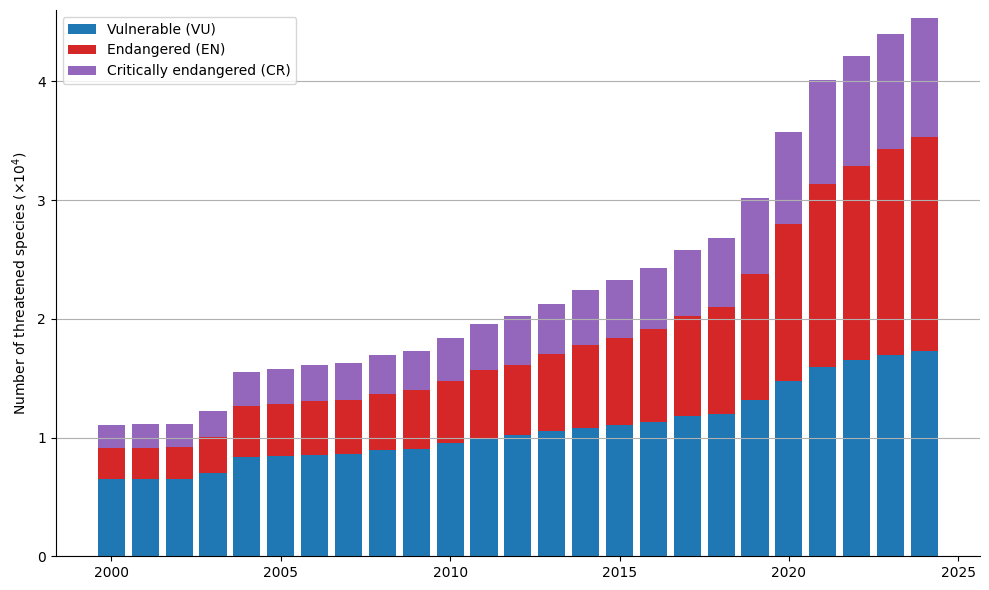

In [14]:

years_full = np.arange(2000, 2025)
yearly = iucn_yearly.set_index("Year").reindex(years_full)
for yr in (2001, 2005):
    yearly.loc[yr] = 0.5 * (yearly.loc[yr - 1] + yearly.loc[yr + 1])
yearly = yearly.sort_index()

cum_rate = yearly["TOTAL"].iloc[0] / yearly["TOTAL"].iloc[-1] - 1
annual_rate = (yearly["TOTAL"].iloc[0] / yearly["TOTAL"].iloc[-1]) ** (1 / 24) - 1
print(f"Cumulative decline 2024->2000: {100*cum_rate:.2f}%, annualized: {100*annual_rate:.2f}%")

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(years_full, yearly["VU"] / 1e4, color="tab:blue", label="Vulnerable (VU)")
ax.bar(years_full, yearly["EN"] / 1e4, bottom=yearly["VU"] / 1e4, color="tab:red", label="Endangered (EN)")
ax.bar(years_full, yearly["CR"] / 1e4, bottom=(yearly["VU"] + yearly["EN"]) / 1e4, color="tab:purple", label="Critically endangered (CR)")
ax.set_ylabel(r"Number of threatened species ($\times 10^4$)")
ax.set_ylim(0, 4.6)
ax.legend(loc="upper left")
ax.grid(axis="y")
plt.tight_layout()


### 4.5 Threatened species as a share of the total, 2000-2024

Same data, expressed as a percentage of the total threatened count each year
rather than an absolute count.


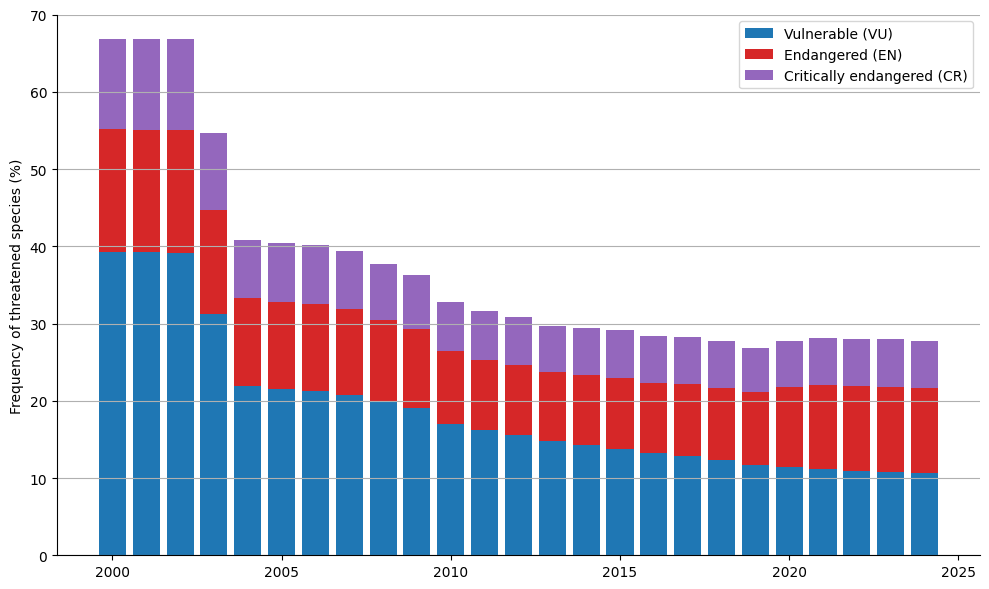

In [15]:

share = yearly[["VU", "EN", "CR"]].div(yearly["TOTAL"], axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(years_full, share["VU"], color="tab:blue", label="Vulnerable (VU)")
ax.bar(years_full, share["EN"], bottom=share["VU"], color="tab:red", label="Endangered (EN)")
ax.bar(years_full, share["CR"], bottom=share["VU"] + share["EN"], color="tab:purple", label="Critically endangered (CR)")
ax.set_ylabel("Frequency of threatened species (%)")
ax.set_ylim(0, 70)
ax.legend(loc="upper right")
ax.grid(axis="y")
plt.tight_layout()


## 5. Island biogeography theory

The classic MacArthur-Wilson theory of island biogeography, the species-area
relationship it implies for habitat loss, and a continuous-time relaxation
model of how species richness actually adjusts toward a new equilibrium
after habitat is lost.


### 5.1 The immigration-extinction equilibrium

Species richness on an island settles where the (declining) immigration
rate of new species meets the (rising) extinction rate of resident species
-- an equilibrium that is lower for islands far from a mainland source or
small in area, and that itself rises with island area via a power law.


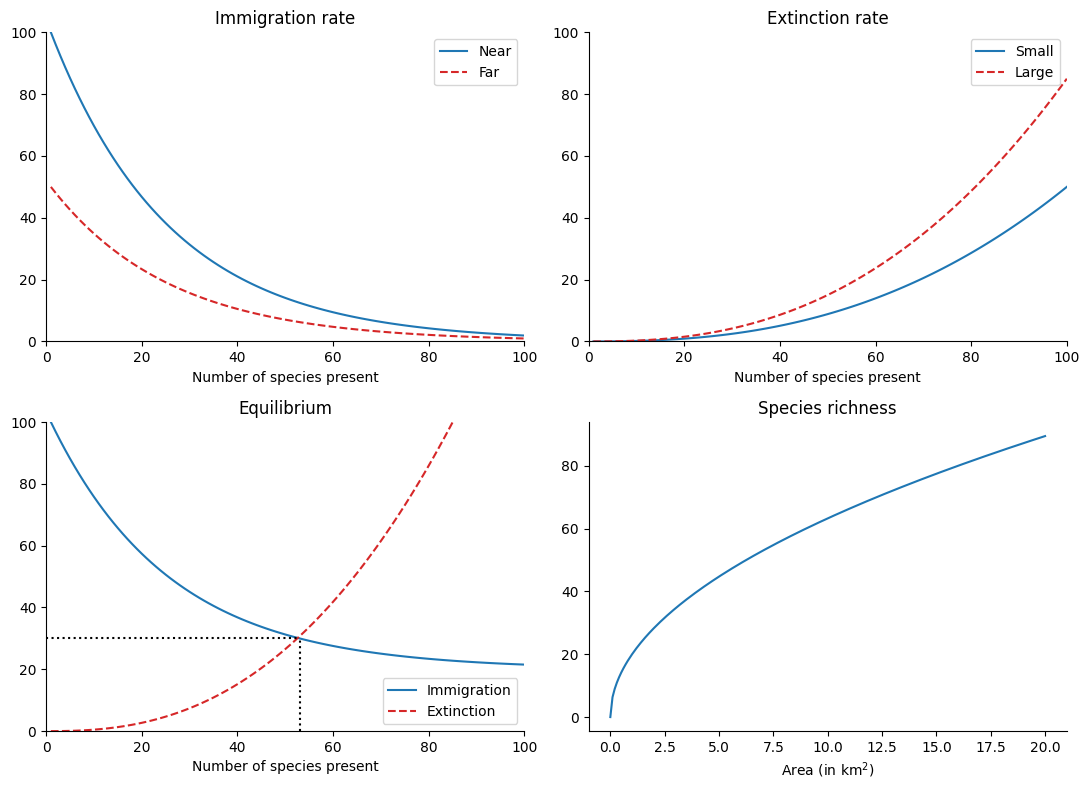

In [16]:

x = np.arange(1, 101)
y_decay = np.exp(-0.04 * x)
immigration_near = 100 * y_decay / y_decay.max()
immigration_far = 50 * y_decay / y_decay.max()

y_power = x ** 2.5
extinction_large = 50 * y_power / y_power.max()
extinction_small = 85 * y_power / y_power.max()

eq_a = 80 * y_decay / y_decay.max() + 20
eq_b = 150 * y_power / y_power.max()
idx_eq = np.argmin(np.abs(eq_a - eq_b))

area = np.arange(0, 20.1, 0.1)
richness_area = 20 * area ** 0.5

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(x, immigration_near, color="tab:blue", label="Near")
axes[0, 0].plot(x, immigration_far, "--", color="tab:red", label="Far")
axes[0, 0].set_title("Immigration rate")
axes[0, 0].legend()

axes[0, 1].plot(x, extinction_large, color="tab:blue", label="Small")
axes[0, 1].plot(x, extinction_small, "--", color="tab:red", label="Large")
axes[0, 1].set_title("Extinction rate")
axes[0, 1].legend()

axes[1, 0].plot(x, eq_a, color="tab:blue", label="Immigration")
axes[1, 0].plot(x, eq_b, "--", color="tab:red", label="Extinction")
axes[1, 0].plot([x[idx_eq]] * 2, [0, eq_a[idx_eq]], ":", color="black")
axes[1, 0].plot([0, x[idx_eq]], [eq_a[idx_eq]] * 2, ":", color="black")
axes[1, 0].set_title("Equilibrium")
axes[1, 0].legend()

axes[1, 1].plot(area, richness_area, color="tab:blue")
axes[1, 1].set_title("Species richness")
axes[1, 1].set_xlabel("Area (in km$^2$)")

for ax in axes.flat[:3]:
    ax.set_xlabel("Number of species present")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

plt.tight_layout()


### 5.2 Species loss implied by habitat loss

Via the species-area power law $S \propto A^z$, a given fractional habitat
loss translates into a smaller fractional species loss whenever $z<1$ --
but the exponent $z$ itself matters a great deal: at $z=0.35$, losing 90% of
habitat area is expected to eventually cost roughly half the resident
species.


In [17]:

loss_habitat = np.array([0, 0.25, 0.50, 0.75, 0.90, 1.00])
z_values = np.array([0.05, 0.10, 0.25, 0.35])
loss_species = 1 - (1 - loss_habitat[None, :]) ** z_values[:, None]

pd.DataFrame(100 * loss_species, index=[f"z={z}" for z in z_values],
             columns=[f"{100*l:.0f}% habitat lost" for l in loss_habitat]).round(1)


,0% habitat lost,25% habitat lost,50% habitat lost,75% habitat lost,90% habitat lost,100% habitat lost
z=0.05,0.0,1.4,3.4,6.7,10.9,100.0
z=0.1,0.0,2.8,6.7,12.9,20.6,100.0
z=0.25,0.0,6.9,15.9,29.3,43.8,100.0
z=0.35,0.0,9.6,21.5,38.4,55.3,100.0


### 5.3 A continuous-time relaxation model of species richness

A generalized logistic-decay model for how species richness $S(t)$ relaxes
toward a new, lower carrying capacity after habitat area (and hence
immigrant pool size $n$) shrinks:
$\dot{S} = -\frac{k}{n^\alpha S_0^\alpha} S^{\alpha+1}$, with closed-form
solution $S(t) = S_0\left(1 + \frac{k\alpha}{n^\alpha}t\right)^{-1/\alpha}$.
$\alpha=0.9$ approximates the (fast-relaxing) neutral model; $\alpha=0.1$
approximates a slow exponential decay. The relaxation time $\tau$ (time to
reach half the initial richness) shortens sharply as $\alpha \to 1$.


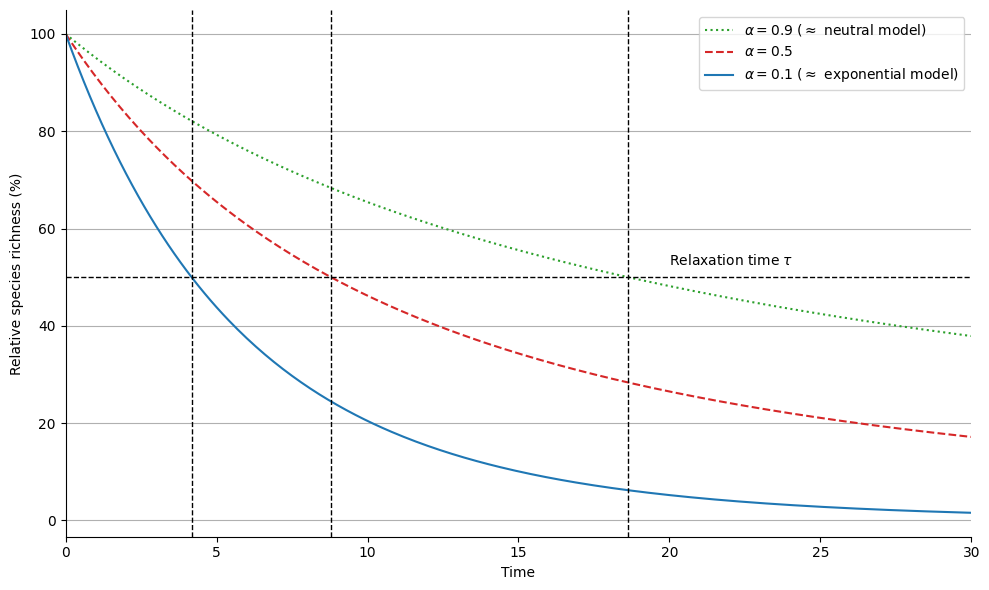

In [18]:

A = 500
k = 0.20
alpha = np.array([0.10, 0.50, 0.90])
rho = 0.90
S0 = np.array([100.0, 100.0, 100.0])
n = rho * A / S0

t = np.arange(0, 30.1, 0.1)
St = S0 * (1 + k * alpha / (n ** alpha) * t[:, None]) ** (-1 / alpha)
tau = (2 ** alpha - 1) * (n ** alpha) / (k * alpha)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, St[:, 2], ":", color="tab:green", label=r"$\alpha=0.9$ ($\approx$ neutral model)")
ax.plot(t, St[:, 1], "--", color="tab:red", label=r"$\alpha=0.5$")
ax.plot(t, St[:, 0], "-", color="tab:blue", label=r"$\alpha=0.1$ ($\approx$ exponential model)")
ax.axhline(50, linestyle="--", color="black", linewidth=1)
ax.text(20, 52.5, "Relaxation time " + r"$\tau$", fontsize=10)
for i in range(3):
    ax.axvline(tau[i], linestyle="--", color="black", linewidth=1)
ax.set_xlabel("Time")
ax.set_ylabel("Relative species richness (%)")
ax.set_xlim(0, 30)
ax.legend()
ax.grid(axis="y")
plt.tight_layout()


### 5.4 Extinction debt

When habitat area drops abruptly (here from $A_0=1000$ to $A=500$), species
richness does not fall instantly to the new equilibrium $\bar{S}$ -- it
relaxes there gradually from the old equilibrium $\bar{S}_0$, so richness
observed shortly after the habitat loss can look misleadingly close to
normal. The shaded gap between the still-elevated observed richness and the
eventual equilibrium is the "extinction debt" -- species effectively
already committed to extinction by past habitat loss, even though they
haven't disappeared yet. Two additional trajectories (released from
arbitrary richness levels of 15 and 12 under the same post-loss dynamics,
integrated numerically and time-shifted to align at $t=0$) show that the
relaxation path is an attractor: wherever richness starts out, it converges
onto the same curve.


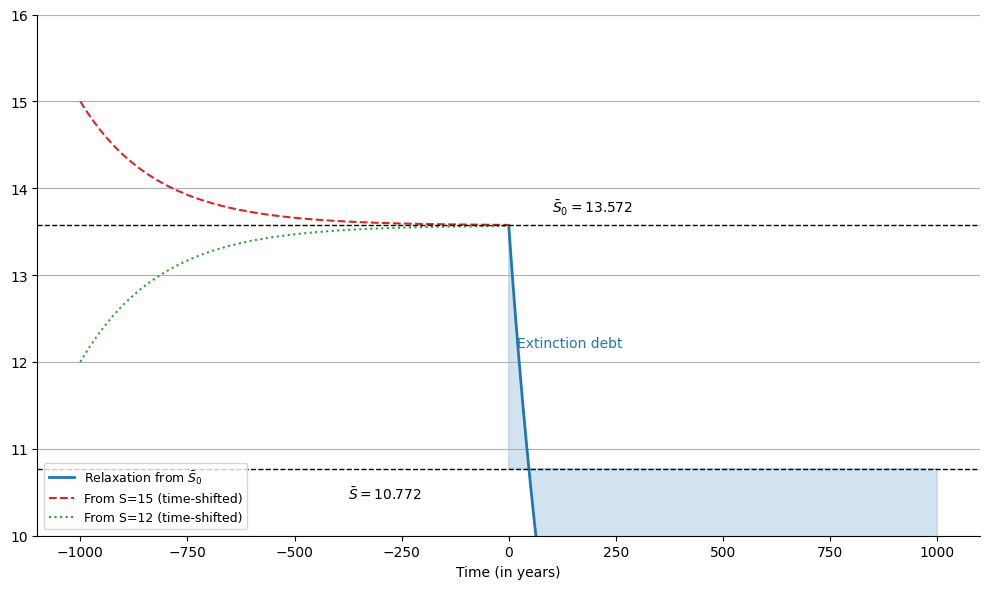

In [19]:

A0, A = 1000, 500
k = 0.10
alpha = 0.50
rho = 10.0
lam = 0.05

S0_bar = (lam * (rho * A0) ** alpha / k) ** (1 / (alpha + 1))
n0 = rho * A0 / S0_bar

S0 = S0_bar
n = rho * A / S0
S_bar = (lam * n ** alpha * S0 ** alpha / k) ** (1 / (alpha + 1))

t = np.arange(0, 1001)
St = S0 * (1 + k * alpha / (n ** alpha) * t) ** (-1 / alpha)

def dSdt(t, S):
    return lam - k / (n0 ** alpha * S0 ** alpha) * S ** (alpha + 1)

sol1 = solve_ivp(dSdt, [0, 1000], [15.0], t_eval=np.arange(0, 1001), max_step=1.0)
sol2 = solve_ivp(dSdt, [0, 1000], [12.0], t_eval=np.arange(0, 1001), max_step=1.0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, St, color="tab:blue", linewidth=2, label="Relaxation from $\\bar{S}_0$")
ax.plot(sol1.t - sol1.t[-1], sol1.y[0], "--", color="tab:red", label="From S=15 (time-shifted)")
ax.plot(sol2.t - sol2.t[-1], sol2.y[0], ":", color="tab:green", label="From S=12 (time-shifted)")
ax.axhline(S0_bar, linestyle="--", color="black", linewidth=1)
ax.axhline(S_bar, linestyle="--", color="black", linewidth=1)
ax.text(100, S0_bar + 0.15, r"$\bar{S}_0=$" + f"{S0_bar:.3f}", fontsize=10)
ax.text(-375, S_bar - 0.35, r"$\bar{S}=$" + f"{S_bar:.3f}", fontsize=10)
ax.fill_between(t, St, S_bar, color="tab:blue", alpha=0.2)
ax.text(20, (S0_bar + S_bar) / 2, "Extinction debt", color="tab:blue", fontsize=10)
ax.set_xlabel("Time (in years)")
ax.set_ylim(10, 16)
ax.legend(loc="lower left", fontsize=9)
ax.grid(axis="y")
plt.tight_layout()


### 5.5 Sensitivity to the relaxation exponent

Only the steady-state table is reproduced here -- the corresponding
closed-form relaxation curve depends on a variable that is never clearly
defined for this case, so it's left out rather than plotted against an
ambiguous reference. The steady-state richness $\bar{S}_0$, effective
immigrant pool $\bar{n}_0$ and equilibrium flux $\dot S_0$ under the
pre-loss area $A_0$, for three values of the relaxation exponent $\alpha$.


In [20]:

A0, A = 1000, 500
k = 0.001
alpha = np.array([0.01, 0.50, 0.90])
rho = 10.0
lam = 0.01

S0_bar = (lam * (rho * A0) ** alpha / k) ** (1 / (alpha + 1))
n0_bar = rho * A0 / S0_bar
dS0 = lam - k / (n0_bar ** alpha * S0_bar ** alpha) * S0_bar ** (alpha + 1)

pd.DataFrame({"alpha": alpha, "S0_bar": S0_bar, "n0_bar": n0_bar, "dS0": dS0}).round(4)


,alpha,S0_bar,n0_bar,dS0
0,0.01,10.7079,933.8928,-0.0
1,0.50,100.0000,100.0000,0.0
2,0.90,263.6651,37.9269,0.0


## 6. Testing the species-area relationship against real island data

Fattorini et al.'s survey of five taxonomic groups (land snails, isopods,
centipedes, tenebrionid beetles, reptiles) across Tyrrhenian and Aegean
islands, read from `chap5_biodiversity_fattorini.xlsx`.


In [21]:

xl = pd.ExcelFile(f"{DATA_DIR}/chap5_biodiversity_fattorini.xlsx")
tyrrhenian_raw = xl.parse("Tyrrhenian")
tyrrhenian_raw.columns = ["Island", "Area", "Land_snails", "Isopods", "Centipedes", "Tenebrionids", "Reptiles"]
aegean_raw = xl.parse("Aegean")
aegean_raw.columns = ["Island", "Area", "Land_snails", "Isopods", "Centipedes", "Tenebrionids", "Reptiles"]
taxa = ["Land_snails", "Centipedes", "Isopods", "Tenebrionids", "Reptiles"]

fitted = xl.parse("Table 1", header=None)
area_units = fitted.iloc[1, 1:8].astype(float).values
tyrrhenian_fit = fitted.iloc[3:8, 1:8].astype(float).values   # rows: land snails, centipedes, isopods, tenebrionids, reptiles
aegean_fit = fitted.iloc[9:14, 1:8].astype(float).values
species_labels = fitted.iloc[3:8, 0].values


### 6.1 The species-area power law across taxa and area units

`Table 1` of the underlying spreadsheet already tabulates expected species
richness $S$ at seven standard area units for each taxon and archipelago.
Backing out the power-law exponent $z$ from
$S(A)/S(1\,\text{km}^2) = A^z$ (averaged across area units) and its
intercept $c=S(1)$ recovers the fitted $S=c\,A^z$ curve for each taxon.


In [22]:

def fit_power_law(fit_table, area_units):
    # S = c * A^z is linear in log-log space, so fit it directly with
    # scipy.stats.linregress on log(S) vs log(A) instead of hand-rolling
    # an average-of-ratios estimate.
    log_area = np.log(area_units)
    c = np.empty(fit_table.shape[0])
    z = np.empty(fit_table.shape[0])
    with np.errstate(invalid="ignore"):
        for i in range(fit_table.shape[0]):
            result = linregress(log_area, np.log(fit_table[i]))
            z[i] = result.slope
            c[i] = np.exp(result.intercept)
    return c, z

c1, z1 = fit_power_law(tyrrhenian_fit, area_units)
c2, z2 = fit_power_law(aegean_fit, area_units)

pd.DataFrame({
    "Taxon": species_labels,
    "c (Tyrrhenian)": c1, "z (Tyrrhenian)": z1,
    "c (Aegean)": c2, "z (Aegean)": z2,
}).round(3)


,Taxon,c (Tyrrhenian),z (Tyrrhenian),c (Aegean),z (Aegean)
0,Land snails,12.274,0.225,9.572,0.184
1,Centipedes,6.281,0.308,3.864,0.243
2,Isopods,9.226,0.262,9.354,0.203
3,Tenebrionids,8.610,0.270,4.055,0.268
4,Reptiles,3.358,0.141,2.716,0.278


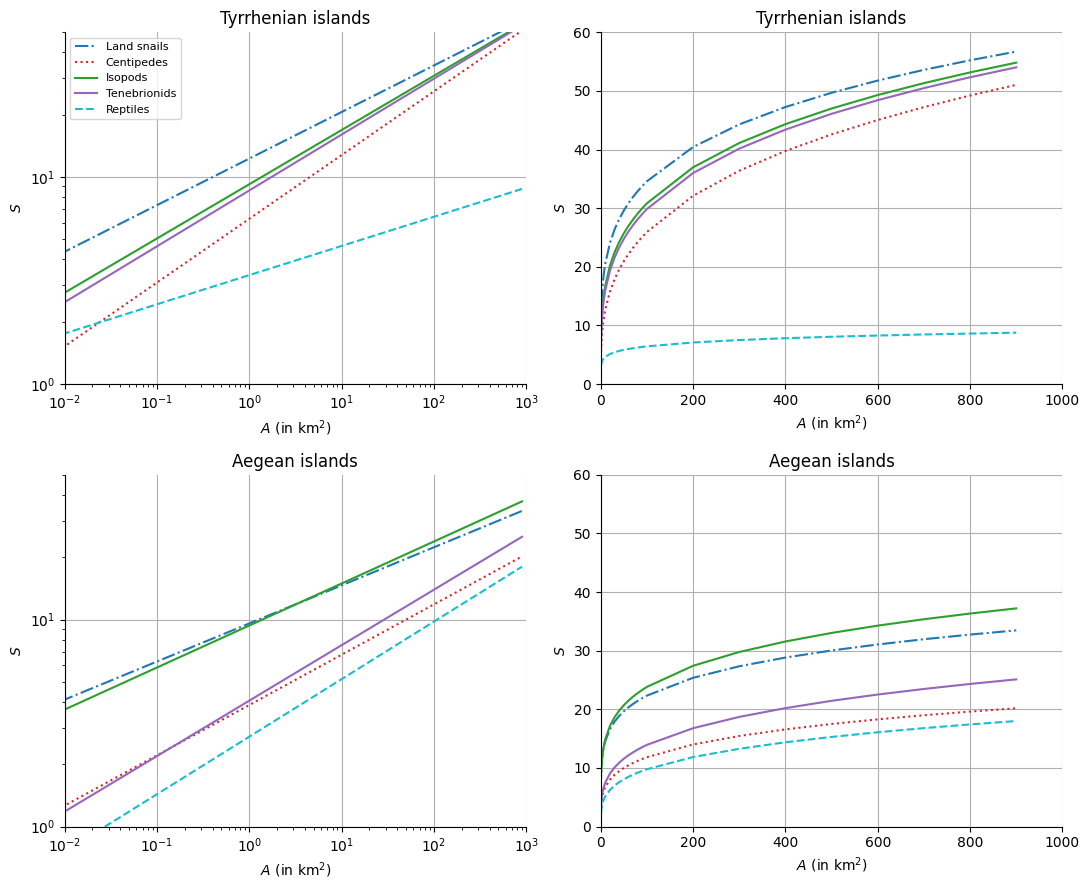

In [23]:

A_grid = np.concatenate([
    np.arange(0.001, 0.01, 0.001), np.arange(0.01, 1, 0.01),
    np.arange(1, 10, 1), np.arange(10, 100, 10), np.arange(100, 1000, 100),
])
S1 = c1[None, :] * A_grid[:, None] ** z1[None, :]
S2 = c2[None, :] * A_grid[:, None] ** z2[None, :]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
colors = ["tab:blue", "tab:red", "tab:green", "tab:purple", "tab:cyan"]
styles = ["-.", ":", "-", "-", "--"]

for row, (S, title) in enumerate([(S1, "Tyrrhenian islands"), (S2, "Aegean islands")]):
    for j in range(len(species_labels)):
        axes[row, 0].plot(A_grid, S[:, j], styles[j], color=colors[j], label=species_labels[j])
        axes[row, 1].plot(A_grid, S[:, j], styles[j], color=colors[j])
    axes[row, 0].set_xscale("log"); axes[row, 0].set_yscale("log")
    axes[row, 0].set_xlim(1e-2, 1e3); axes[row, 0].set_ylim(1, 50)
    axes[row, 1].set_xlim(0, 1e3); axes[row, 1].set_ylim(0, 60)
    for col in range(2):
        axes[row, col].set_title(title)
        axes[row, col].set_xlabel("$A$ (in km$^2$)")
        axes[row, col].set_ylabel("$S$")
        axes[row, col].grid(True, which="major")

axes[0, 0].legend(fontsize=8, loc="upper left")
plt.tight_layout()


### 6.2 Direct regression on raw island data: land snails

Rather than backing $z$ out of the pre-tabulated fit, regress $\log S$ on
$\log A$ directly against the raw per-island land-snail counts on the
Tyrrhenian islands.


In [24]:

land_snails = tyrrhenian_raw.dropna(subset=["Land_snails"])
x = np.log(land_snails["Area"].astype(float))
y = np.log(land_snails["Land_snails"].astype(float))

X = np.column_stack([np.ones(len(x)), x])
beta = np.linalg.solve(X.T @ X, X.T @ y)
c_hat, z_hat = np.exp(beta[0]), beta[1]

print(f"Islands used: {len(land_snails)}")
print(f"log-log regression: log(S) = {beta[0]:.4f} + {beta[1]:.4f} * log(A)")
print(f"=> S = {c_hat:.4f} * A^{z_hat:.4f}")

land_snails[["Island", "Area", "Land_snails"]].sort_values("Area")


Islands used: 18
log-log regression: log(S) = 2.5084 + 0.2247 * log(A)
=> S = 12.2849 * A^0.2247


,Island,Area,Land_snails
1,Argentarola,0.0120,4.0
6,Cerboli,0.0506,8.0
11,Formica di Grosseto,0.1450,5.0
2,Basiluzzo,0.2700,11.0
16,Gorgona,2.2700,24.0
14,Giannutri,2.3900,19.0
29,Panarea,3.3800,22.0
0,Alicudi,5.0000,11.0
9,Filicudi,9.0000,20.0
30,Pianosa,10.4100,28.0


### 6.3 Regressed vs. tabulated exponents, all taxa and both archipelagos

Comparing the exponent backed out of the pre-tabulated fit (section 6.1)
against a direct log-log regression on the raw per-island data, taxon by
taxon.


In [25]:

rows = []
for name, raw, c_tab, z_tab in [
    ("Tyrrhenian", tyrrhenian_raw, c1, z1),
    ("Aegean", aegean_raw, c2, z2),
]:
    for j, taxon in enumerate(taxa):
        sub = raw.dropna(subset=[taxon])
        x = np.log(sub["Area"].astype(float))
        y = np.log(sub[taxon].astype(float))
        X = np.column_stack([np.ones(len(x)), x])
        beta = np.linalg.solve(X.T @ X, X.T @ y)
        rows.append({
            "Archipelago": name, "Taxon": species_labels[j] if j < len(species_labels) else taxon,
            "n islands": len(sub),
            "z (tabulated)": z_tab[j], "z (regressed)": beta[1],
            "c (tabulated)": c_tab[j], "c (regressed)": np.exp(beta[0]),
        })

pd.DataFrame(rows).round(3)


,Archipelago,Taxon,n islands,z (tabulated),z (regressed),c (tabulated),c (regressed)
0,Tyrrhenian,Land snails,18,0.225,0.225,12.274,12.285
1,Tyrrhenian,Centipedes,32,0.308,0.308,6.281,6.275
2,Tyrrhenian,Isopods,28,0.262,0.262,9.226,9.216
3,Tyrrhenian,Tenebrionids,46,0.270,0.270,8.610,8.607
4,Tyrrhenian,Reptiles,28,0.141,0.141,3.358,3.360
5,Aegean,Land snails,65,0.184,0.184,9.572,9.567
6,Aegean,Centipedes,43,0.243,0.243,3.864,3.865
7,Aegean,Isopods,43,0.203,0.203,9.354,9.360
8,Aegean,Tenebrionids,32,0.268,0.265,4.055,4.125
9,Aegean,Reptiles,56,0.278,0.277,2.716,2.720
